Generation diffusion: wrong nr of timesteps

# Yield Curve Generator — Inference Notebook

This notebook loads a **pre-trained** Conditional Autoregressive Diffusion Model and generates synthetic yield curve paths.

**No GPU, no training data required** — only the model file.

### What you need
| File | Description |
|------|-------------|
| `yield_diffusion_model.pt` | Trained model weights + normalization statistics |

Place it in the **same folder** as this notebook before running.

## Step 1 — Imports

In [36]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # avoids common OpenMP crash on Windows

DEVICE = torch.device("cpu")   # CPU-only — no GPU needed
print(f"Running on: {DEVICE}")

Running on: cpu


## Step 2 — Model Architecture

In [37]:
class ResBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim),
            nn.GroupNorm(8, dim),
            nn.SiLU(),
            nn.Linear(dim, dim)
        )

    def forward(self, x):
        return x + self.net(x)


class CondResNetSequential(nn.Module):
    """cond_dim = 14  (3 macro features + 11 yield curve points from previous step)"""
    def __init__(self, input_dim=11, cond_dim=14, hidden_dim=256):
        super().__init__()
        self.time_mlp = nn.Sequential(
            nn.Linear(1, hidden_dim), nn.SiLU(), nn.Linear(hidden_dim, hidden_dim)
        )
        self.macro_mlp = nn.Sequential(
            nn.Linear(cond_dim, hidden_dim), nn.SiLU(), nn.Linear(hidden_dim, hidden_dim)
        )
        self.input_proj = nn.Linear(input_dim, hidden_dim)
        self.res_blocks = nn.ModuleList([ResBlock(hidden_dim) for _ in range(4)])
        self.final_proj = nn.Linear(hidden_dim, input_dim)

    def forward(self, x, t, c):
        t_emb = self.time_mlp(t.float().unsqueeze(-1) / 1000.0)
        c_emb = self.macro_mlp(c)
        h = self.input_proj(x) + t_emb + c_emb
        for block in self.res_blocks:
            h = block(h)
        return self.final_proj(h)


print("Model classes defined.")

Model classes defined.


## Step 3 — Diffusion Engine (sampling only)

In [38]:
class DiffusionEngine:
    def __init__(self, model, T=300, device="cpu"):
        self.model = model
        self.T = T
        self.device = device
        self.beta = torch.linspace(1e-4, 0.02, T, device=device)
        self.alpha_hat = torch.cumprod(1.0 - self.beta, dim=0)

    @torch.no_grad()
    def sample(self, c_scenario):
        c_scenario = c_scenario.to(self.device)
        n = c_scenario.shape[0]
        x = torch.randn((n, 11), device=self.device)
        for i in reversed(range(self.T)):
            t = torch.full((n,), i, dtype=torch.long, device=self.device)
            v = self.model(x, t, c_scenario)
            a_hat = self.alpha_hat[i]
            x0_recons = torch.sqrt(a_hat) * x - torch.sqrt(1 - a_hat) * v
            if i > 0:
                a_hat_prev = self.alpha_hat[i - 1]
                direction_xt = torch.sqrt(1 - a_hat_prev) * (
                    (x - torch.sqrt(a_hat) * x0_recons) / torch.sqrt(1 - a_hat)
                )
                x = torch.sqrt(a_hat_prev) * x0_recons + direction_xt
            else:
                x = x0_recons
        return x


print("DiffusionEngine defined.")

DiffusionEngine defined.


## Step 4 — Load the Pre-Trained Model

In [39]:
MODEL_PATH = "yield_diffusion_model.pt"   # <-- change path if needed

checkpoint = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=False)

hp = checkpoint["hyperparameters"]
model = CondResNetSequential(
    input_dim=hp["input_dim"],
    cond_dim=hp["cond_dim"],
    hidden_dim=hp["hidden_dim"]
)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

# Normalization stats — everything needed is stored inside the .pt file
stats  = checkpoint["stats"]
mu_y   = stats["mu_y"]    # scalar — yield mean
std_y  = stats["std_y"]   # scalar — yield std
mu_c   = stats["mu_c"]    # shape (3,) — macro means  [FedFunds, CPI, GDP]
std_c  = stats["std_c"]   # shape (3,) — macro stds

mu_c_vals  = mu_c.values  if hasattr(mu_c,  "values") else np.array(mu_c)
std_c_vals = std_c.values if hasattr(std_c, "values") else np.array(std_c)

diffuser = DiffusionEngine(model, T=hp["T"], device=str(DEVICE))

print("Model loaded successfully!")
print(f"  Yield  mean={mu_y:.4f}, std={std_y:.4f}")
print(f"  Macro  mean={mu_c_vals.round(4)}, std={std_c_vals.round(4)}")

Model loaded successfully!
  Yield  mean=2.2196, std=1.6158
  Macro  mean=[1.34700000e+00 2.22489100e+02 1.75223128e+04], std=[1.5512000e+00 2.4078100e+01 1.8458504e+03]


## Step 5 — Define Your Scenario Inputs

You need to supply two things:

1. **Starting yield curve** — the 11 yield values (in %) at `t=0` (e.g. today's curve).
2. **Future macro forecasts** — one row per time step with `[FedFunds, CPI, GDP]`.

The yield maturities the model expects (in order) are:
`1M, 3M, 6M, 1Y, 2Y, 3Y, 5Y, 7Y, 10Y, 20Y, 30Y`

Edit the values below to match your scenario.

In [40]:
N_STEPS = 12   # number of future monthly steps to generate

# --- Starting yield curve (%, raw values) ---
# Order: 1M, 3M, 6M, 1Y, 2Y, 3Y, 5Y, 7Y, 10Y, 20Y, 30Y
start_yield_raw = np.array([5.30, 5.35, 5.40, 5.20, 4.80, 4.60, 4.40, 4.35, 4.30, 4.50, 4.45])

# --- Future macro forecasts (one row per step) ---
# Columns: FedFunds (%), CPI (%), GDP growth (%)
future_macro_raw = pd.DataFrame({
    "FedFunds": [5.25, 5.25, 5.00, 4.75, 4.50, 4.25, 4.00, 3.75, 3.75, 3.50, 3.50, 3.25],
    "CPI":      [3.2,  3.1,  3.0,  2.9,  2.8,  2.7,  2.6,  2.5,  2.4,  2.4,  2.3,  2.3],
    "GDP":      [2.5,  2.4,  2.3,  2.2,  2.1,  2.0,  2.0,  1.9,  1.9,  1.8,  1.8,  1.7],
})

assert len(future_macro_raw) == N_STEPS, f"Need exactly {N_STEPS} macro rows"

# Normalise inputs using the saved statistics
start_yield_norm = torch.tensor(
    (start_yield_raw - mu_y) / std_y, dtype=torch.float32
)
future_macro_norm = torch.tensor(
    (future_macro_raw.values - mu_c_vals) / std_c_vals, dtype=torch.float32
)

print("Inputs ready.")
print(f"  Starting curve (normalised): {start_yield_norm.numpy().round(3)}")

Inputs ready.
  Starting curve (normalised): [1.906 1.937 1.968 1.845 1.597 1.473 1.349 1.318 1.288 1.411 1.38 ]


## Step 6 — Generate Scenarios

In [41]:
def generate_path(model, diffuser, start_yield_norm, future_macros_norm, steps=12):
    """Returns a (steps+1, 11) tensor: the starting curve + all generated steps."""
    model.eval()
    current = start_yield_norm.clone().unsqueeze(0).to(diffuser.device)  # (1, 11)
    path = [current]
    for t in range(steps):
        cond = torch.cat([future_macros_norm[t].unsqueeze(0).to(diffuser.device), current], dim=-1)
        current = diffuser.sample(cond)
        path.append(current)
    return torch.cat(path, dim=0)


N_SCENARIOS = 500
YIELD_LABELS = ["1M", "3M", "6M", "1Y", "2Y", "3Y", "5Y", "7Y", "10Y", "20Y", "30Y"]

all_paths = []
for s in range(N_SCENARIOS):
    path_norm = generate_path(model, diffuser, start_yield_norm, future_macro_norm, steps=N_STEPS)
    path = path_norm.cpu().numpy() * std_y + mu_y   # back to % space
    all_paths.append(path)
    print(f"Scenario {s+1}/{N_SCENARIOS} — final 10Y yield: {path[-1, 8]:.3f}%")

print("\nDone.")

Scenario 1/500 — final 10Y yield: 5.140%
Scenario 2/500 — final 10Y yield: 5.046%
Scenario 3/500 — final 10Y yield: 4.627%
Scenario 4/500 — final 10Y yield: 5.127%
Scenario 5/500 — final 10Y yield: 5.180%
Scenario 6/500 — final 10Y yield: 5.028%
Scenario 7/500 — final 10Y yield: 4.626%
Scenario 8/500 — final 10Y yield: 4.797%
Scenario 9/500 — final 10Y yield: 5.027%
Scenario 10/500 — final 10Y yield: 5.193%
Scenario 11/500 — final 10Y yield: 5.342%
Scenario 12/500 — final 10Y yield: 4.392%
Scenario 13/500 — final 10Y yield: 4.816%
Scenario 14/500 — final 10Y yield: 4.071%
Scenario 15/500 — final 10Y yield: 4.360%
Scenario 16/500 — final 10Y yield: 4.539%
Scenario 17/500 — final 10Y yield: 5.527%
Scenario 18/500 — final 10Y yield: 4.520%
Scenario 19/500 — final 10Y yield: 5.522%
Scenario 20/500 — final 10Y yield: 5.538%
Scenario 21/500 — final 10Y yield: 5.096%
Scenario 22/500 — final 10Y yield: 4.656%
Scenario 23/500 — final 10Y yield: 5.357%
Scenario 24/500 — final 10Y yield: 4.051%
S

## Step 6.5 — Export Scenarios to CSV

Save all generated scenarios to a CSV file for comparison with other models.

In [42]:
# Create a comprehensive DataFrame with all scenarios
output_rows = []

for scenario_idx, path in enumerate(all_paths):
    for time_step in range(len(path)):
        row = {
            "Scenario": scenario_idx + 1,
            "TimeStep": time_step,
        }
        # Add each yield maturity as a column
        for maturity_idx, maturity_label in enumerate(YIELD_LABELS):
            row[f"Yield_{maturity_label}"] = path[time_step, maturity_idx]
        output_rows.append(row)

df_scenarios = pd.DataFrame(output_rows)

# Delete old version if it exists, then save to CSV
output_filename = "generated_autogressive_yield_scenarios.csv"
if os.path.exists(output_filename):
    os.remove(output_filename)
    print(f"Deleted existing file: '{output_filename}'")

df_scenarios.to_csv(output_filename, index=False)

print(f"Saved {len(all_paths)} scenarios to '{output_filename}'")
print(f"Total rows: {len(df_scenarios)} (={N_SCENARIOS} scenarios × {N_STEPS+1} time steps)")
print(f"\nFirst few rows:")
print(df_scenarios.head(15))

Deleted existing file: 'generated_autogressive_yield_scenarios.csv'
Saved 500 scenarios to 'generated_autogressive_yield_scenarios.csv'
Total rows: 6500 (=500 scenarios × 13 time steps)

First few rows:
    Scenario  TimeStep   Yield_1M   Yield_3M   Yield_6M  Yield_1Y  Yield_2Y  \
0          1         0   5.300000   5.350000   5.400000  5.200000  4.800000   
1          1         1   6.125919   5.848288   5.788139  5.161500  4.928483   
2          1         2   6.869733   6.586736   6.345078  5.474143  5.290462   
3          1         3   7.422364   7.241660   6.744074  5.523508  5.755775   
4          1         4   8.021803   7.644270   7.174413  5.980340  6.010440   
5          1         5   8.631145   8.278756   7.657939  6.320804  6.470519   
6          1         6   9.313802   8.874201   8.216672  6.873888  7.097539   
7          1         7  10.089127   9.572001   8.771512  7.542380  7.910260   
8          1         8  10.907111  10.254762   9.294551  8.049805  8.250877   
9      

## Step 7 — Plot: 10Y Yield Evolution Across Scenarios

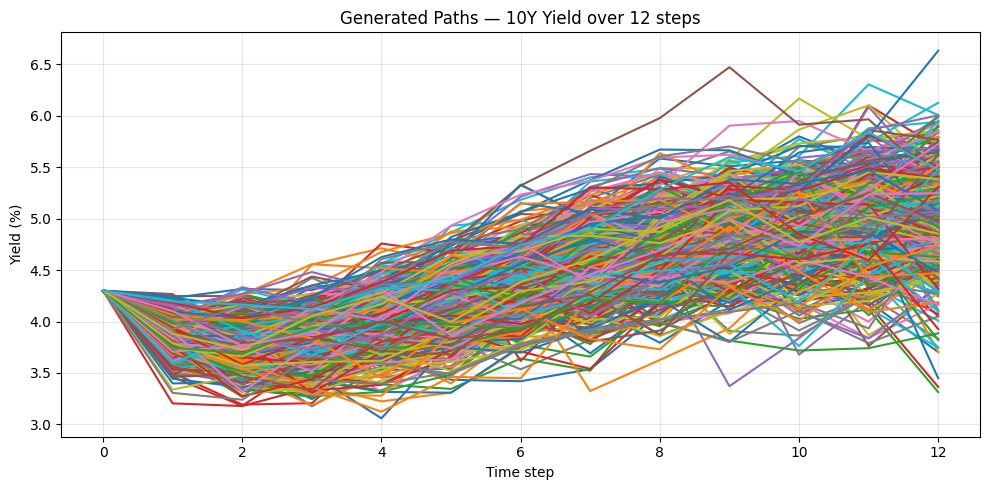

In [43]:
fig, ax = plt.subplots(figsize=(10, 5))
for s, path in enumerate(all_paths):
    ax.plot(path[:, 8], label=f"Scenario {s+1}")

ax.set_title(f"Generated Paths — 10Y Yield over {N_STEPS} steps")
ax.set_xlabel("Time step")
ax.set_ylabel("Yield (%)")
#ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 8 — Plot: Full Yield Curve Shape Over Time

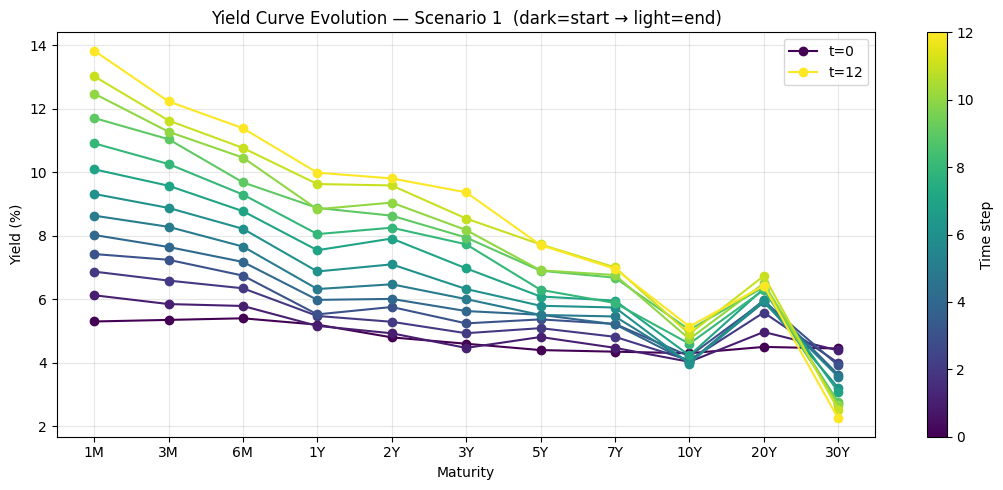

In [44]:
SCENARIO_TO_PLOT = 0   # 0-based index

path = all_paths[SCENARIO_TO_PLOT]
fig, ax = plt.subplots(figsize=(11, 5))
cmap = plt.cm.viridis
for step_idx in range(len(path)):
    color = cmap(step_idx / max(len(path) - 1, 1))
    label = f"t={step_idx}" if step_idx in (0, len(path) - 1) else None
    ax.plot(range(len(YIELD_LABELS)), path[step_idx], color=color,
            marker="o", linewidth=1.5, label=label)

ax.set_xticks(range(len(YIELD_LABELS)))
ax.set_xticklabels(YIELD_LABELS)
ax.set_title(f"Yield Curve Evolution — Scenario {SCENARIO_TO_PLOT + 1}  (dark=start → light=end)")
ax.set_xlabel("Maturity")
ax.set_ylabel("Yield (%)")
ax.legend()
ax.grid(True, alpha=0.3)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=N_STEPS))
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Time step")
plt.tight_layout()
plt.show()